# Algortitmo de Deutsche

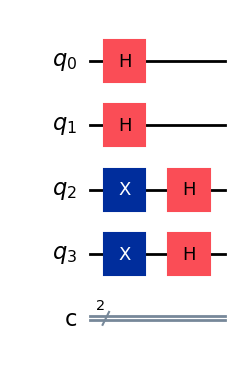

In [42]:
from qiskit import QuantumCircuit

n=2
qc = QuantumCircuit(n+2,n)

for i in range(n):
    qc.h(i)

qc.x(n)
qc.h(n)

qc.x(n+1)
qc.h(n+1)

qc.draw(output="mpl")


In [ ]:
import numpy as np 
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import Aer
from qiskit import transpile

key_10 = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0], 
    [0, 1, 0, 0, 0, 0, 0, 0], 
    [0, 0, 1, 0, 0, 0, 0, 0], 
    [0, 0, 0, 1, 0, 0, 0, 0], 
    [0, 0, 0, 0, 0, 1, 0, 0], 
    [0, 0, 0, 0, 1, 0, 0, 0], 
    [0, 0, 0, 0, 0, 0, 1, 0], 
    [0, 0, 0, 0, 0, 0, 0, 1], 
])


key_00 = np.array([
    [0, 1, 0, 0, 0, 0, 0, 0], 
    [1, 0, 0, 0, 0, 0, 0, 0], 
    [0, 0, 1, 0, 0, 0, 0, 0], 
    [0, 0, 0, 1, 0, 0, 0, 0], 
    [0, 0, 0, 0, 1, 0, 0, 0], 
    [0, 0, 0, 0, 0, 1, 0, 0], 
    [0, 0, 0, 0, 0, 0, 1, 0], 
    [0, 0, 0, 0, 0, 0, 0, 1], 
])


N = 2**n

s_state = np.ones(N) / np.sqrt(N)
s_outer = np.outer(s_state, s_state)
diffusion_operator = 2 * s_outer - np.identity(N)
mean_inversion = diffusion_operator

gates = [
         UnitaryGate(key_10, label="Uf key=10"),
         UnitaryGate(mean_inversion, label="inversion")
        ]


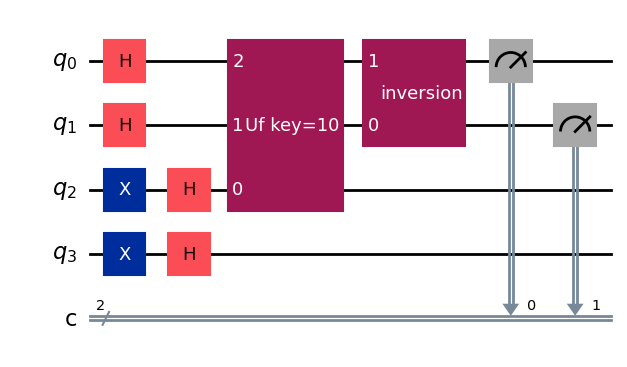

In [44]:
qc.append(gates[0], [2,1,0])
qc.append(gates[1],[1,0])

qc.measure(range(n),range(n))
display(qc.draw(output="mpl"))

In [45]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("qasm_simulator")

job = backend.run(transpile(qc, backend), shots=1024)
result = job.result()


counts = result.get_counts()
print(counts)


{'01': 1024}
